In [ ]:
'''
l1- norm regularization
l2 norm
dropout
dense weight matrix -> overfitting
'''

'\nl1- norm regularization\nl2 norm\ndropout\ndense weight matrix -> overfitting\n'

In [ ]:
#dropout

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,  models, callbacks
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train),(x_test, y_test)=tf.keras.datasets.mnist.load_data()

In [ ]:
# Normalize (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten 28x28 → 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

In [ ]:
print(x_train.shape)

(60000, 784)


In [ ]:
x_train_small = x_train[:1000]
y_train_small = y_train[:1000]

In [ ]:
model_overfit = models.Sequential([
    layers.Dense(2000, activation='relu', input_shape=(784,)),
    layers.Dense(2000, activation='relu'),
    layers.Dense(2000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [ ]:
model_overfit.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
chk_point_overfit = callbacks.ModelCheckpoint(
    filepath="best_overfit_model.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

chk_point_dropout = callbacks.ModelCheckpoint(
    filepath="best_dropout_model.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

In [ ]:
history_overfit = model_overfit.fit(
    x_train_small, y_train_small,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[chk_point_overfit]
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 2.8955e-06
Epoch 1: val_accuracy improved from -inf to 0.90570, saving model to best_overfit_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step - accuracy: 1.0000 - loss: 2.8813e-06 - val_accuracy: 0.9057 - val_loss: 0.7250
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 2.1544e-06
Epoch 2: val_accuracy improved from 0.90570 to 0.90580, saving model to best_overfit_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 256ms/step - accuracy: 1.0000 - loss: 2.1562e-06 - val_accuracy: 0.9058 - val_loss: 0.7284
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 2.5771e-06
Epoch 3: val_accuracy did not improve from 0.90580
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - accuracy: 1.0000 - loss: 2.5605e-06 - val_accuracy: 0.9057 - val_loss: 0.7312
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 1.0000 - loss: 1.6366e-06
Epoch 4: val_accuracy did not improve 

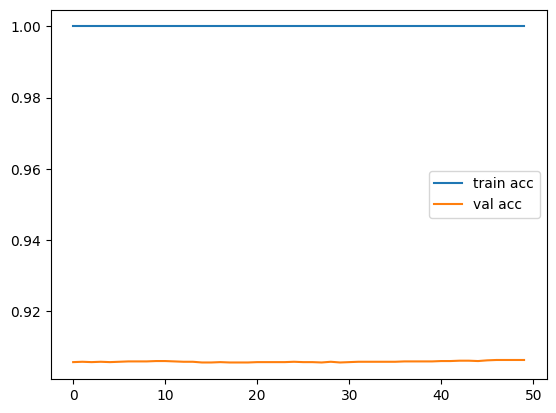

In [ ]:
plt.plot(history_overfit.history['accuracy'], label='train acc')
plt.plot(history_overfit.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [ ]:
#dropout

model_dropout = models.Sequential([
    layers.Dense(2000, activation='relu', input_shape=(784,)),
    layers.Dropout(0.5),

    layers.Dense(2000, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(2000, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_dropout = model_dropout.fit(
    x_train_small, y_train_small,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[chk_point_dropout]
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9863 - loss: 0.0440
Epoch 1: val_accuracy did not improve from 0.90610
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - accuracy: 0.9863 - loss: 0.0445 - val_accuracy: 0.8976 - val_loss: 1.0636
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9869 - loss: 0.0510
Epoch 2: val_accuracy did not improve from 0.90610
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - accuracy: 0.9871 - loss: 0.0505 - val_accuracy: 0.8820 - val_loss: 1.2955
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9914 - loss: 0.0529
Epoch 3: val_accuracy improved from 0.90610 to 0.90730, saving model to best_dropout_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.9913 - loss: 0.0533 - val_accuracy: 0.9073 - val_loss: 0.9909
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9954 - loss: 0.0480
Epoch 4: val_accuracy did not improve from 0.90730
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.995

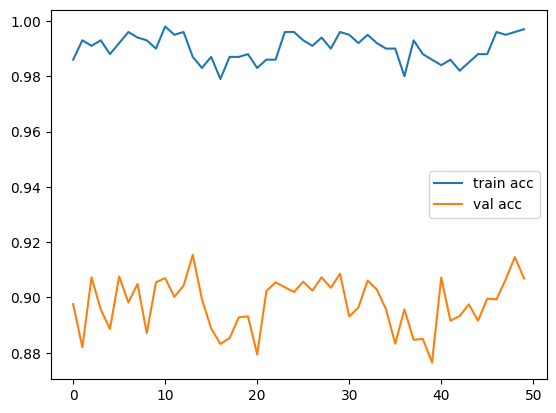

In [ ]:
plt.plot(history_dropout.history['accuracy'], label='train acc')
plt.plot(history_dropout.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()